# Synthetic Parameter Recovery via pyVBMC — condition-stratified, NO linking function

Validates the full inference pipeline end-to-end: generate synthetic data from **known** GP
parameters under the condition-stratified design, then run the same pyVBMC machinery used on
the real data (`model-study9-vbmc-no-linking.ipynb`) and check whether it recovers the true
`(length_scale, mu_0)`.

This combines two simplifications relative to the original condition-stratified recovery notebook
(`model-synthetic-recovery-vbmc-condition-stratified.ipynb`):

- **Condition-stratified**: each condition (diet / personality / physical / heterogeneous) gets
  its own independent coherence field over `[x_test, x_train_cond[c]]`, drawn from the same GP
  hyperparameters `(length_scale, mu_0, output_scale)`.
- **No linking function**: predicted prevalence for a test feature is just the coherence itself,
  `pz1_j = sigmoid(y_test_j)` — no per-feature Beta-mixture shapes. Ratings are scored under a
  single **global** Beta concentration `kappa`, shared across ALL conditions and features:
  `r_ij ~ Beta(kappa * pz1_j, kappa * (1 - pz1_j))`.

Removing the linking function removes the nuisance-parameter flexibility that can absorb
cross-feature prevalence differences — so if `(length_scale, mu_0)` are recoverable anywhere,
it should be here. This notebook is the maximally-identifiable, condition-stratified end of the
spectrum: a direct test of whether stratification *and* removing linking-function flexibility
together restore identifiability, beyond what either alone buys back.

**Generative model:**
1. Each condition trains generic utterances about its own region only (`u_train_cond[c]` fixed
   by design — not a latent draw).
2. For each condition, sample an **independent** latent coherence draw
   `y_c = (y_test_c, y_train_c) ~ MVN(mu_0, K_θ)` over `[x_test, x_train_cond[c]]`, at the true
   `(length_scale, mu_0, output_scale)`.
3. `pz1_test_c[j] = sigmoid(y_test_c[j])` is the TRUE predicted prevalence (no linking function
   in between). Each participant in condition `c` draws a rating directly from
   `Beta(kappa_true * pz1_test_c[j], kappa_true * (1 - pz1_test_c[j]))`, rounded to the 0-100
   slider grid. `kappa_true` is shared across conditions.

Then recover `(length_scale, mu_0)` with pyVBMC: per eval, sample each condition's coherences via
NUTS, fit the single SHARED `kappa` once across all conditions' pooled responses (weighted by
each condition's own posterior-mean `pz1`), then score each condition's draws under that shared
`kappa` and sum — identical machinery to the real-data no-linking condition-stratified model.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
from scipy.special import betainc
from scipy.optimize import minimize_scalar
from pyvbmc import VBMC

from model_jax import rbf_kernel, make_log_density_fn_joint   # only the GP+utterance sampler; no linking fns

print(f"backend: {jax.default_backend()}")

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


backend: cpu


## Ground-truth parameters and feature geometry

True params are interior to the VBMC bounds (not on a boundary), so recovery is a fair test.
Feature embeddings and the per-condition trained regions are the real ones, so the spatial
geometry — and hence how identifiable the length scale is — matches the real experiment.
`kappa_true` replaces the kind-linked/not-kind-linked Beta shapes from the linking-function
version: it's the single global concentration that sets how tightly ratings cluster around the
true coherence.

In [2]:
# Ground-truth parameters to recover
TRUE_PARAMS = {
    'length_scale': 2.1,
    'mu_0':         0.5,
    'output_scale': 1.5,
    'beta':         3.0,
}
KAPPA_TRUE = 6.0   # single global Beta concentration shared across conditions/features

with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

CONDITIONS  = ['diet', 'personality', 'physical', 'heterogeneous']
CAT_OF_COND = {'diet':'diet_preferences', 'personality':'personality_behaviors', 'physical':'physical'}
CAT_SHORT   = {'diet_preferences':'diet', 'personality_behaviors':'personality', 'physical':'physical'}

x_train_cond, u_train_cond = {}, {}
for c in CONDITIONS:
    sub = train_df[train_df.in_heterogenous] if c == 'heterogeneous' else train_df[train_df.category == CAT_OF_COND[c]]
    x_train_cond[c] = jnp.array(sub[['x_2d', 'y_2d']].values)
    u_train_cond[c] = jnp.zeros(len(sub), dtype=jnp.int32)   # all generic, localized to the region -- fixed by design
    print(f"  {c:<14}: {len(sub)} trained features")

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':'can eat spicy food','diet_breakfast_late_1':'eat breakfast very late',
    'diet_five_meals_day_1':'eat five meals a day','diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':'put pepper on all their foods','pers_cry_easily_1':'cry easily',
    'pers_collect_rocks_1':'like to collect rocks','pers_like_to_dance_1':'like to dance',
    'pers_like_highfive_1':'like to give high-fives','pers_read_books_1':'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue','phys_can_snap_toes_1':'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears','phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':'snore when they sleep'}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
x_test     = jnp.array([feat_idx.loc[n, ['x_2d','y_2d']].values for n in test_feature_names])  # (J,2)
test_trait = [CAT_SHORT[feat_idx.loc[n, 'category']] for n in test_feature_names]
J = x_test.shape[0]

print(f"True params: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']}, kappa={KAPPA_TRUE}")

  diet          : 15 trained features
  personality   : 15 trained features
  physical      : 15 trained features
  heterogeneous : 15 trained features
True params: ls=2.1, mu_0=0.5, kappa=6.0


## 1. Sample per-condition latent coherences

`u_train_cond` is fixed by design (every condition hears only generic statements about its own
region) — it's not a generative latent here. The only thing we sample per condition is the GP
coherence field over `[x_test, x_train_cond[c]]`; with no linking function, this coherence IS the
predicted prevalence.

In [3]:
rng = np.random.default_rng(37)

# test first then train (matches make_log_density_fn_joint convention) -- one independent
# GP draw PER CONDITION, since each condition has its own trained region / coherence field.
y_test_true_cond, pz1_test_true_cond = {}, {}
for c in CONDITIONS:
    n_train_c = x_train_cond[c].shape[0]
    X_all = jnp.vstack([x_test, x_train_cond[c]])
    mu    = jnp.full(J + n_train_c, TRUE_PARAMS['mu_0'])
    K     = rbf_kernel(X_all, TRUE_PARAMS['length_scale'], TRUE_PARAMS['output_scale'])

    y_all = rng.multivariate_normal(np.array(mu), np.array(K))
    y_test_true_cond[c]   = y_all[:J]
    pz1_test_true_cond[c] = 1 / (1 + np.exp(-y_test_true_cond[c]))

    print(f"  {c:<14}: y_test range [{y_test_true_cond[c].min():.2f}, {y_test_true_cond[c].max():.2f}]  "
          f"pz1 range [{pz1_test_true_cond[c].min():.2f}, {pz1_test_true_cond[c].max():.2f}]  "
          f"(realized mean y_test={y_test_true_cond[c].mean():.3f}; true mu_0="
          f"{TRUE_PARAMS['mu_0']} -- sampling scatter means recovered mu_0 may shift slightly)")

  diet          : y_test range [-1.16, -0.63]  pz1 range [0.24, 0.35]  (realized mean y_test=-0.865; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  personality   : y_test range [0.20, 0.31]  pz1 range [0.55, 0.58]  (realized mean y_test=0.264; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  physical      : y_test range [0.24, 0.98]  pz1 range [0.56, 0.73]  (realized mean y_test=0.608; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  heterogeneous : y_test range [-0.39, -0.29]  pz1 range [0.40, 0.43]  (realized mean y_test=-0.339; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)


## 2. Sample ratings per condition (discretized to the 0-100 slider grid)

No linking function: each rating is drawn directly from
`Beta(kappa_true * pz1, kappa_true * (1 - pz1))`, where `pz1` is that condition's own true
coherence at that test feature. `kappa_true` is shared across conditions and features — there are
no per-feature nuisance parameters to absorb the cross-feature contrast, so the coherences alone
must explain why some features are rated higher than others.

  diet          : 100 participants -> responses (100, 15)
  personality   : 100 participants -> responses (100, 15)
  physical      : 100 participants -> responses (100, 15)
  heterogeneous : 100 participants -> responses (100, 15)
stacked responses_all: (400, 15)


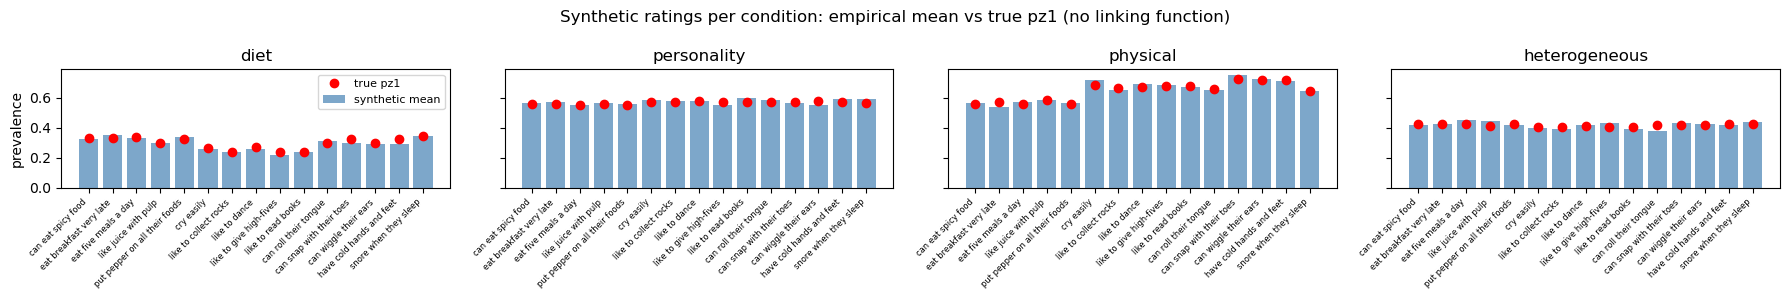

In [4]:
N_PARTICIPANTS_COND = {'diet': 100, 'personality': 100, 'physical': 100, 'heterogeneous': 100}

responses_cond = {}
for c in CONDITIONS:
    Nc = N_PARTICIPANTS_COND[c]
    p  = np.clip(pz1_test_true_cond[c], 1e-4, 1 - 1e-4)   # (J,)
    a  = KAPPA_TRUE * p
    b  = KAPPA_TRUE * (1.0 - p)
    draws = rng.beta(a[None, :], b[None, :], size=(Nc, J))
    responses_cond[c] = jnp.array(np.round(draws * 100) / 100)   # discretize to slider grid
    print(f"  {c:<14}: {Nc} participants -> responses {responses_cond[c].shape}")

# stacked in condition order -- used to fit the single shared kappa across all participants
responses_all = jnp.concatenate([responses_cond[c] for c in CONDITIONS], axis=0)
N_cond = {c: int(responses_cond[c].shape[0]) for c in CONDITIONS}
print(f"stacked responses_all: {responses_all.shape}")

fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
for ax, c in zip(axes, CONDITIONS):
    ax.bar(range(J), np.array(responses_cond[c].mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
    ax.plot(range(J), pz1_test_true_cond[c], 'ro', label='true pz1')
    ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=6)
    ax.set_title(c)
axes[0].set_ylabel('prevalence'); axes[0].legend(fontsize=8)
fig.suptitle('Synthetic ratings per condition: empirical mean vs true pz1 (no linking function)')
plt.tight_layout(); plt.show()

## Prevalence-as-coherence likelihood

`prevalence_loglik` scores ratings under `Beta(mean=pz1, concentration=kappa)` using the same
interval (binned) trick as the linking model, so the discrete slider is handled correctly.
`fit_kappa` optimizes the single global concentration (a 1-D solve) — the no-linking analogue of
fitting the per-feature Beta-mixture shapes, but with one scalar instead of 60 parameters, shared
across ALL conditions and features.

In [5]:
H = 1.0 / 200.0   # half a slider bin

def prevalence_loglik(responses, pz1, kappa):
    '''Sum log P(r_ij in its bin) under Beta(mean=pz1_j, conc=kappa). responses (N,J), pz1 (J,).'''
    r = np.asarray(responses, dtype=np.float64)
    p = np.clip(np.asarray(pz1, dtype=np.float64), 1e-4, 1 - 1e-4)
    a = kappa * p                       # (J,)
    b = kappa * (1.0 - p)
    lo = np.clip(r - H, 0.0, 1.0)       # (N,J)
    hi = np.clip(r + H, 0.0, 1.0)
    P  = betainc(a[None, :], b[None, :], hi) - betainc(a[None, :], b[None, :], lo)
    return float(np.sum(np.log(np.maximum(P, 1e-300))))

def fit_kappa(responses, pz1):
    '''Best single global concentration kappa for predicted prevalences pz1 (1-D solve).'''
    res = minimize_scalar(lambda lk: -prevalence_loglik(responses, pz1, float(np.exp(lk))),
                          bounds=(np.log(0.5), np.log(500.0)), method='bounded')
    return float(np.exp(res.x))

FIT_KAPPA   = True
KAPPA_FIXED = 4.0   # used only if FIT_KAPPA is False

print("defined prevalence_loglik, fit_kappa")

defined prevalence_loglik, fit_kappa


## Inference: pyVBMC over (length_scale, mu_0)

Per evaluation: sample each condition's coherences via NUTS, fit the single SHARED `kappa` ONCE
across all conditions' pooled responses (weighted by each condition's own posterior-mean `pz1`),
then score each condition's thinned draws under that shared `kappa` (logsumexp) and sum across
conditions. `output_scale` and `beta` are fixed at their true values. No linking-function shapes
at all — the only nuisance parameter is the single scalar `kappa`.

In [6]:
FIXED_PARAMS = {
    'output_scale': TRUE_PARAMS['output_scale'],
    'beta':         TRUE_PARAMS['beta'],
}

N_WARMUP   = 300
N_SAMPLES  = 800        # per condition; 4 chains per eval
STEP       = 5          # thinning
MAX_EVALS  = 150        # VBMC budget knob

def condition_pz1_draws(x_train_c, u_train_c, params):
    '''Thinned coherence draws (S, J) = sigmoid(y_test) for one condition's trained region.'''
    ldf = make_log_density_fn_joint(u_train_c, x_train_c, x_test, params)
    ip  = {'training_coherences': jnp.zeros(x_train_c.shape[0]), 'test_coherences': jnp.zeros(J)}
    k = jax.random.PRNGKey(0); k, wk = jax.random.split(k)
    w = blackjax.window_adaptation(blackjax.nuts, ldf)
    (st, npar), _ = w.run(wk, ip, num_steps=N_WARMUP)
    nuts = blackjax.nuts(ldf, **npar); step = jax.jit(lambda s, key: nuts.step(key, s))
    tc = []
    for key in jax.random.split(k, N_SAMPLES)[:-1]:
        st, _ = step(st, key)
        tc.append(np.array(st.position['test_coherences']))
    return np.array(jax.nn.sigmoid(np.array(tc)[::STEP]))   # (S, J)

print(f"MCMC: {N_WARMUP} warmup, {N_SAMPLES} samples, thin {STEP} -> ~{(N_SAMPLES-1)//STEP} draws per condition")

MCMC: 300 warmup, 800 samples, thin 5 -> ~159 draws per condition


In [7]:
eval_count = [0]
eval_log   = []   # [(phi, log_joint_val, noise_std), ...]

def log_joint(phi):
    '''Condition-stratified log joint, NO linking function: predicted prevalence = coherence.

    Per eval: sample each condition's coherences; fit the single SHARED kappa ONCE across all
    conditions' pooled responses (weighted by each condition's own posterior-mean pz1); then
    score each condition's draws against that shared kappa and sum. phi = [log_ls, mu_0].
    '''
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    length_scale = float(np.exp(log_ls))
    eval_count[0] += 1
    print(f"  eval {eval_count[0]:3d}: ls={length_scale:.3f}  mu_0={mu_0:.3f}", end="  ")

    # same priors as the linking-function run
    log_prior_ls  = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    log_prior_mu0 = float(-0.5 * mu_0 ** 2)
    log_prior = log_prior_ls + log_prior_mu0

    params = {**FIXED_PARAMS, 'length_scale': length_scale, 'mu_0': mu_0}

    # 1. per-condition coherence draws (= predicted prevalence directly, no linking fn)
    pz1_draws = {c: condition_pz1_draws(x_train_cond[c], u_train_cond[c], params) for c in CONDITIONS}
    pz1_bar   = {c: pz1_draws[c].mean(axis=0) for c in CONDITIONS}

    # 2. SHARED kappa: fit once across all conditions, by maximizing the SUM of each condition's
    #    own log-likelihood (each condition scored against its own pz1_bar, same shared kappa)
    def _pooled_loglik(kappa):
        return sum(prevalence_loglik(responses_cond[c], pz1_bar[c], kappa) for c in CONDITIONS)
    kappa = (float(np.exp(minimize_scalar(lambda lk: -_pooled_loglik(float(np.exp(lk))),
                                           bounds=(np.log(0.5), np.log(500.0)), method='bounded').x))
             if FIT_KAPPA else KAPPA_FIXED)

    # 3. score each condition's draws under the shared kappa; logsumexp over draws; sum
    total_ll, var_terms = 0.0, []
    for c in CONDITIONS:
        S = pz1_draws[c].shape[0]
        ll_s = [prevalence_loglik(responses_cond[c], pz1_draws[c][s], kappa) for s in range(S)]
        total_ll += float(scipy_logsumexp(ll_s) - np.log(S))
        var_terms.append(np.var(ll_s))

    noise_std = float(np.sqrt(sum(var_terms)))   # combined MC noise across conditions
    if not np.isfinite(total_ll):
        total_ll, noise_std = -1e6, 1.0

    log_joint_val = float(total_ll + log_prior)
    print(f"kappa={kappa:6.2f}  log_lik={total_ll:.1f}  noise_std={noise_std:.2f}  log_joint={log_joint_val:.1f}")
    eval_log.append((np.array(phi, dtype=float), log_joint_val, noise_std))
    return log_joint_val, max(noise_std, 1.0)

In [8]:
# --- pyVBMC varG-squeeze patch (same bug fix as the other notebooks) ---
import pyvbmc.vbmc.variational_optimization as _vopt
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig_gp_log_joint = _vopt._gp_log_joint
    def _gp_log_joint_scalar_varg(*args, **kwargs):
        out = list(_orig_gp_log_joint(*args, **kwargs))
        if out[2] is not None:
            out[2] = float(np.squeeze(out[2]))
        return tuple(out)
    _gp_log_joint_scalar_varg._varg_squeeze_patch = True
    _vopt._gp_log_joint = _gp_log_joint_scalar_varg
    print("patched _gp_log_joint (varG squeeze)")

# Start AWAY from the truth so recovery is a real test (true ls=2.1, mu_0=0.5)
x0  = np.array([np.log(0.3), 0.0])
lb  = np.array([np.log(0.03), -4.0])
ub  = np.array([np.log(2.5),   4.0])     # ~3x cloud diameter (0.78); above this = trait-blind
plb = np.array([np.log(0.08), -2.0])
pub = np.array([np.log(1.0),   2.0])
print(f"Start: ls={np.exp(x0[0]):.2f}, mu_0={x0[1]:.2f}  (true: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']})")

vbmc = VBMC(log_joint, x0, lb, ub, plb, pub,
            options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS})
vbmc_result, vbmc_stats = vbmc.optimize()

patched _gp_log_joint (varG squeeze)
Start: ls=0.30, mu_0=0.00  (true: ls=2.1, mu_0=0.5)
Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=0.300  mu_0=0.000  kappa=  2.61  log_lik=-27136.6  noise_std=1463.72  log_joint=-27136.7
  eval   2: ls=0.290  mu_0=0.530  kappa=  2.32  log_lik=-27538.7  noise_std=1620.36  log_joint=-27538.9
  eval   3: ls=0.541  mu_0=-1.496  kappa=  2.76  log_lik=-26833.0  noise_std=1385.49  log_joint=-26834.1
  eval   4: ls=0.109  mu_0=1.770  kappa=  1.78  log_lik=-30112.4  noise_std=1461.23  log_joint=-30114.5
  eval   5: ls=0.390  mu_0=0.306  kappa=  2.32  log_lik=-27440.9  noise_std=1517.27  log_joint=-27441.0
  eval   6: ls=0.317  mu_0=1.542  ka

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar subtract
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar multiply
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),


  eval  28: ls=2.500  mu_0=-1.301  kappa=  2.42  log_lik=-27212.3  noise_std=1022.58  log_joint=-27213.7
  eval  29: ls=1.502  mu_0=-2.697  kappa=  2.69  log_lik=-26749.2  noise_std=965.44  log_joint=-26753.1
  eval  30: ls=2.486  mu_0=-2.640  kappa=  2.67  log_lik=-26979.5  noise_std=911.95  log_joint=-26983.5
     4         30      -26906.09       196.06     16476.78        2   3.89e+05     
  eval  31: ls=2.499  mu_0=-3.111  kappa=  2.83  log_lik=-26837.2  noise_std=898.54  log_joint=-26842.6
  eval  32: ls=2.395  mu_0=-3.317  kappa=  2.88  log_lik=-26593.8  noise_std=948.38  log_joint=-26599.8
  eval  33: ls=2.484  mu_0=-0.282  kappa=  2.08  log_lik=-27654.0  noise_std=1259.23  log_joint=-27654.6
  eval  34: ls=2.495  mu_0=-3.551  kappa=  2.68  log_lik=-26604.5  noise_std=844.80  log_joint=-26611.3
  eval  35: ls=2.474  mu_0=-3.042  kappa=  2.74  log_lik=-26569.8  noise_std=1042.62  log_joint=-26575.0
     5         35      -27083.43       261.26       305.39        2   7.34e+03   

## Recovery results

Posterior over `(length_scale, mu_0)` vs the true values (red). Good recovery = the true point
sits inside the bulk of the posterior. Note `mu_0` may land slightly off the true value because
each condition's realized GP draw mean differs from `mu_0` — that's expected sampling scatter,
not a pipeline error.

param             true   post mean  post median                95% CI
length_scale     2.100       2.457        2.482   [2.259, 2.500]
mu_0             0.500      -3.997       -3.997   [-3.999, -3.993]

convergence: no  (evals: 150, ELBO: -26483.6)


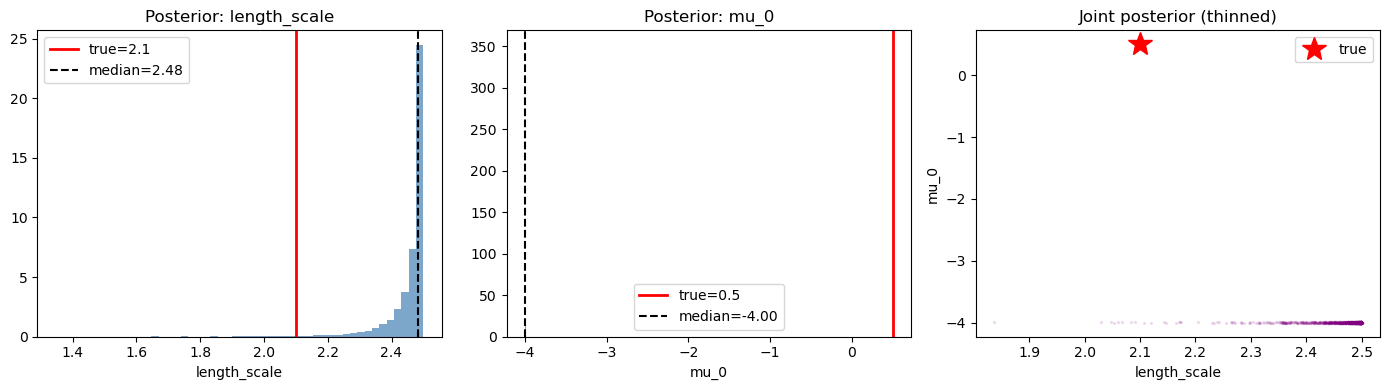

In [9]:
phi_samples, _ = vbmc_result.sample(int(1e4))
ls_samples  = np.exp(phi_samples[:, 0])
mu0_samples = phi_samples[:, 1]

ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']
print(f"{'param':<14}{'true':>8}{'post mean':>12}{'post median':>13}{'95% CI':>22}")
print(f"{'length_scale':<14}{ls_true:>8.3f}{ls_samples.mean():>12.3f}{np.median(ls_samples):>13.3f}"
      f"   [{np.percentile(ls_samples,2.5):.3f}, {np.percentile(ls_samples,97.5):.3f}]")
print(f"{'mu_0':<14}{mu0_true:>8.3f}{mu0_samples.mean():>12.3f}{np.median(mu0_samples):>13.3f}"
      f"   [{np.percentile(mu0_samples,2.5):.3f}, {np.percentile(mu0_samples,97.5):.3f}]")
print(f"\nconvergence: {vbmc_stats['convergence_status']}  (evals: {vbmc_stats['func_count']}, "
      f"ELBO: {vbmc_stats['elbo']:.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Posterior: length_scale'); axes[0].legend()

axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Posterior: mu_0'); axes[1].legend()

axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].plot(ls_true, mu0_true, 'r*', ms=18, label='true')
axes[2].set_xlabel('length_scale'); axes[2].set_ylabel('mu_0')
axes[2].set_title('Joint posterior (thinned)'); axes[2].legend()
plt.tight_layout(); plt.show()

## Forward pass: predicted prevalence (= coherence) vs true pz1, per condition

With no linking function, the model's predicted prevalence is just the posterior-mean coherence
per feature. Compare each condition's prediction (at the recovered `(length_scale, mu_0)`) against
that condition's TRUE `pz1` and against the raw empirical mean rating.

Forward pass at posterior mean: ls=2.457, mu_0=-3.997
  [diet          ] kappa=  1.43   r(pred, true pz1)=-0.233   r(pred, empirical mean)=-0.001
  [personality   ] kappa=  6.18   r(pred, true pz1)=+0.608   r(pred, empirical mean)=+0.250
  [physical      ] kappa=  4.54   r(pred, true pz1)=+0.203   r(pred, empirical mean)=+0.214
  [heterogeneous ] kappa=  3.08   r(pred, true pz1)=-0.722   r(pred, empirical mean)=-0.562


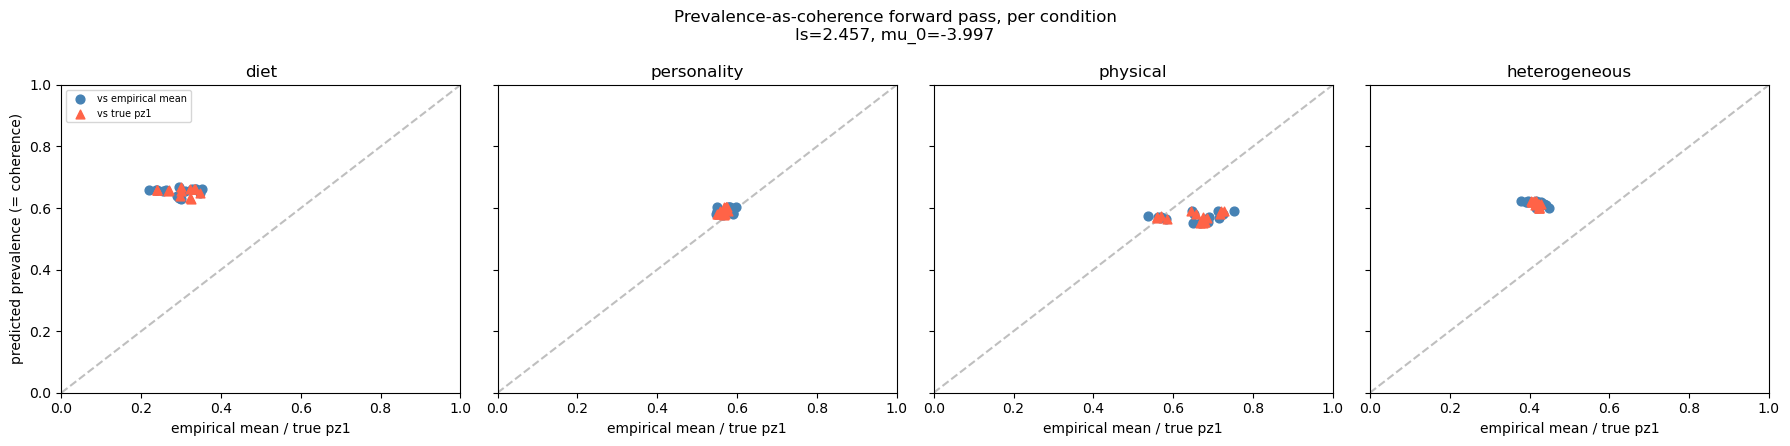

In [10]:
ls_rec, mu0_rec = float(ls_samples.mean()), float(mu0_samples.mean())
print(f"Forward pass at posterior mean: ls={ls_rec:.3f}, mu_0={mu0_rec:.3f}")
params_best = {**FIXED_PARAMS, 'length_scale': ls_rec, 'mu_0': mu0_rec}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)
for ax, c in zip(axes, CONDITIONS):
    pred_prevalence = condition_pz1_draws(x_train_cond[c], u_train_cond[c], params_best).mean(0)  # (J,)
    empirical_mean  = np.array(responses_cond[c].mean(axis=0))
    true_pz1        = pz1_test_true_cond[c]

    kappa_best = fit_kappa(responses_cond[c], pred_prevalence) if FIT_KAPPA else KAPPA_FIXED
    r_pred_true = np.corrcoef(true_pz1, pred_prevalence)[0, 1]
    r_pred_emp  = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
    print(f"  [{c:<14}] kappa={kappa_best:6.2f}   r(pred, true pz1)={r_pred_true:+.3f}   "
          f"r(pred, empirical mean)={r_pred_emp:+.3f}")

    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, zorder=0)
    ax.scatter(empirical_mean, pred_prevalence, s=40, color='steelblue', label='vs empirical mean', zorder=3)
    ax.scatter(true_pz1, pred_prevalence, s=40, color='tomato', marker='^', label='vs true pz1', zorder=3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('empirical mean / true pz1'); ax.set_title(c)
axes[0].set_ylabel('predicted prevalence (= coherence)'); axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle(f'Prevalence-as-coherence forward pass, per condition\nls={ls_rec:.3f}, mu_0={mu0_rec:.3f}')
plt.tight_layout(); plt.show()

## 1D recovery — isolate each parameter

To separate "each parameter is individually unidentifiable" from "the two are confounded in the
joint fit", recover each one alone with the other **fixed at its true value**:

- **lengthscale only** (mu_0 fixed at true)
- **mu_0 only** (lengthscale fixed at true)

Interpretation: if a parameter recovers well alone but not in the joint 2D fit, the problem is the
joint ridge/confound between them. If it fails even alone, it's individually unidentifiable from
this data. Uses the same condition-stratified, shared-kappa, no-linking-function likelihood as the
2D fit above, with a lighter VBMC budget (`MAX_EVALS_1D`) since 1D problems converge faster.

In [11]:
# Shared likelihood body (condition-stratified MCMC + once-per-eval shared-kappa fit, no
# linking function), reused by both 1D objectives.
import pyvbmc.vbmc.variational_optimization as _vopt   # ensure varG-squeeze patch is active
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig = _vopt._gp_log_joint
    def _patched(*a, **k):
        out = list(_orig(*a, **k))
        out[2] = None if out[2] is None else float(np.squeeze(out[2]))
        return tuple(out)
    _patched._varg_squeeze_patch = True
    _vopt._gp_log_joint = _patched

def _loglik_noise(length_scale, mu_0):
    params = {**FIXED_PARAMS, 'length_scale': float(length_scale), 'mu_0': float(mu_0)}

    pz1_draws = {c: condition_pz1_draws(x_train_cond[c], u_train_cond[c], params) for c in CONDITIONS}
    pz1_bar   = {c: pz1_draws[c].mean(axis=0) for c in CONDITIONS}

    def _pooled_loglik(kappa):
        return sum(prevalence_loglik(responses_cond[c], pz1_bar[c], kappa) for c in CONDITIONS)
    kappa = (float(np.exp(minimize_scalar(lambda lk: -_pooled_loglik(float(np.exp(lk))),
                                           bounds=(np.log(0.5), np.log(500.0)), method='bounded').x))
             if FIT_KAPPA else KAPPA_FIXED)

    total_ll, var_terms = 0.0, []
    for c in CONDITIONS:
        S = pz1_draws[c].shape[0]
        ll_s = [prevalence_loglik(responses_cond[c], pz1_draws[c][s], kappa) for s in range(S)]
        total_ll += float(scipy_logsumexp(ll_s) - np.log(S))
        var_terms.append(np.var(ll_s))

    noise_std = float(np.sqrt(sum(var_terms)))
    if not np.isfinite(total_ll):
        total_ll, noise_std = -1e6, 1.0
    return total_ll, max(noise_std, 1.0)

_n_ls = [0]
def log_joint_ls_only(phi):
    '''1D: recover lengthscale only; mu_0 held at the TRUE value.'''
    log_ls = float(phi[0]); ls = float(np.exp(log_ls))
    _n_ls[0] += 1
    ll, ns = _loglik_noise(ls, TRUE_PARAMS['mu_0'])
    lp = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    print(f"  [ls-only] {_n_ls[0]:3d}: ls={ls:.3f}  log_lik={ll:.1f}  noise={ns:.1f}")
    return float(ll + lp), ns

_n_mu = [0]
def log_joint_mu_only(phi):
    '''1D: recover mu_0 only; lengthscale held at the TRUE value.'''
    mu_0 = float(phi[0])
    _n_mu[0] += 1
    ll, ns = _loglik_noise(TRUE_PARAMS['length_scale'], mu_0)
    lp = float(-0.5 * mu_0 ** 2)
    print(f"  [mu-only] {_n_mu[0]:3d}: mu_0={mu_0:.3f}  log_lik={ll:.1f}  noise={ns:.1f}")
    return float(ll + lp), ns

MAX_EVALS_1D = 80   # lighter than the 2D run; 1D problems converge faster
print("defined 1D objectives: log_joint_ls_only, log_joint_mu_only")

defined 1D objectives: log_joint_ls_only, log_joint_mu_only


Reshaping x0 to row vector.
Reshaping lower bounds to (1, 1).
Reshaping upper bounds to (1, 1).
Reshaping plausible lower bounds to (1, 1).
Reshaping plausible upper bounds to (1, 1).
vbmc:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds PLB and PUB. Expanding the plausible bounds...
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  [ls-only]   1: ls=1.500  log_lik=-27465.1  noise=1388.6
  [ls-only]   2: ls=0.313  log_lik=-27448.0  noise=1652.1
  [ls-only]   3: ls=0.600  log_lik=-27618.1  noise=1557.1
  [ls-only]   4: ls=1.366  log_lik=-27795.5  noise=1257.4
  [ls-only]   5: ls=1.305  log_lik=-27453.9  noise=1279.8
  [ls-only]   6: ls=0.458  log_lik=-27286.4  noise=1653.7
  [ls-only]   7: ls=0.114  log_lik=-28233.9  noise=1354.7
  [ls-only]   8: ls=0.176  log_lik=-27818.6  noise=1444.0
  [ls-only]   9: ls=0.568  log_lik=-27

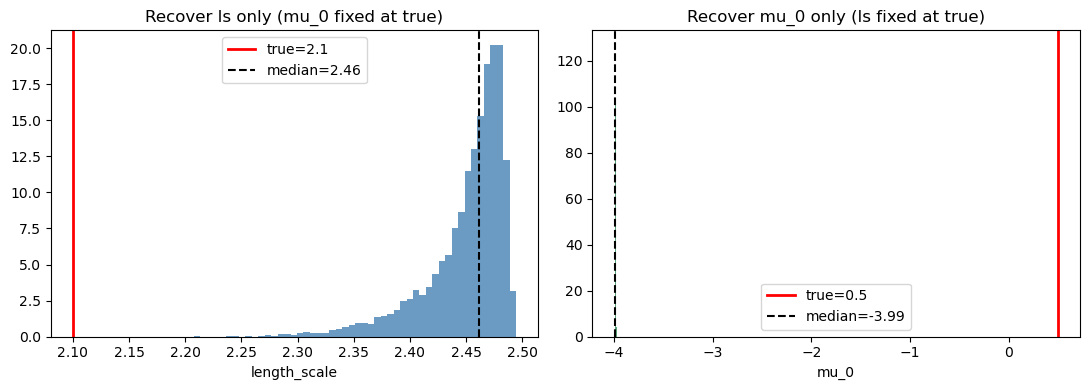

In [12]:
ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']

# --- lengthscale only (mu_0 fixed at true) ---
vbmc_ls = VBMC(log_joint_ls_only,
               np.array([np.log(1.5)]), np.array([np.log(0.03)]), np.array([np.log(2.5)]),
               np.array([np.log(0.08)]), np.array([np.log(1.0)]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_ls, stats_ls = vbmc_ls.optimize()
ls_post = np.exp(res_ls.sample(int(1e4))[0][:, 0])

# --- mu_0 only (lengthscale fixed at true) ---
vbmc_mu = VBMC(log_joint_mu_only,
               np.array([1.0]), np.array([-4.0]), np.array([4.0]),
               np.array([-2.0]), np.array([2.0]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_mu, stats_mu = vbmc_mu.optimize()
mu0_post = res_mu.sample(int(1e4))[0][:, 0]

print(f"\nlengthscale-only:  true={ls_true}   median={np.median(ls_post):.3f}   "
      f"95% CI [{np.percentile(ls_post,2.5):.3f}, {np.percentile(ls_post,97.5):.3f}]   "
      f"({stats_ls['convergence_status']})")
print(f"mu_0-only:         true={mu0_true}   median={np.median(mu0_post):.3f}   "
      f"95% CI [{np.percentile(mu0_post,2.5):.3f}, {np.percentile(mu0_post,97.5):.3f}]   "
      f"({stats_mu['convergence_status']})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ls_post, bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_post), color='k', ls='--', label=f'median={np.median(ls_post):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Recover ls only (mu_0 fixed at true)'); axes[0].legend()
axes[1].hist(mu0_post, bins=50, density=True, color='seagreen', alpha=0.8)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_post), color='k', ls='--', label=f'median={np.median(mu0_post):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Recover mu_0 only (ls fixed at true)'); axes[1].legend()
plt.tight_layout(); plt.show()